# Simulation-Based Disaggregation of Education
**Author:** Jiří Landsmann

Target: share of population with tertiary education (%), known for the 14 Kraje, estimated for the 77 Okresy.

Both methods follow the same pipeline:

1. **Simulate** Okres labels that respect the official Kraj value,
2. **train** a regressor (Linear Regression, Decision Tree, Random Forest, Gradient Boosting) on Okres features → simulated labels,
3. **predict** every Okres and **anchor**: rescale within each Kraj so that the weighted Okres average equals the official Kraj value.

They differ in step 1:

* **Method A - noise simulation** (the original method). Okresy are clustered within each Kraj on their features; labels are the Kraj value plus a random offset per cluster and random noise per district. Repeated over many random seeds.
* **Method B - feature-informed simulation.** A ridge regression is fitted on the 14 Kraj rows and applied to the Okresy; after anchoring this gives labels that carry the feature signal instead of noise. Deterministic.

Baselines (Kraj mean, direct Kraj → Okres models) are computed in `baselines.ipynb` and repeated here for the side-by-side comparison.

**Evaluation protocol.** The real Okres values are used *only* to compute the metrics below -
never for fitting, clustering or tuning. Prague is both a Kraj and its only Okres, so every
anchored method reproduces it exactly; it is excluded from all metrics (76 districts remain).

| Metric | Meaning |
|---|---|
| MAE, RMSE | error in percentage points |
| R² | share of variance across all districts explained |
| Within-Kraj r | correlation of true vs. predicted *deviations from the Kraj value* - how well districts are ranked inside their region (NaN for the Kraj-mean baseline) |
| Anchor gap | largest difference between the weighted Okres average and the official Kraj value (0 = consistent with the official aggregate) |

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

sys.path.insert(0, str(Path.cwd().parent))  # repo root, for the shared `approx` package
import approx
from approx import plotting

RESULTS = Path("results")
PLOTS = Path("plots")
RESULTS.mkdir(exist_ok=True)
pd.set_option("display.precision", 3)

## 1. Data

**Features** - household composition from Census 2021, as shares of all households: one-family, multi-family and one-person households (the fourth category, multi-person non-family households, is implied because the shares sum to one).

**Weight** - number of households, used whenever Okres values are averaged up to a Kraj.

In [2]:
ds = approx.load_education()
print(f"{len(ds.okres)} okresy, {len(ds.kraj)} kraje, features: {ds.features}")
display(ds.kraj)

77 okresy, 14 kraje, features: ['share_one_family', 'share_multi_family', 'share_single_person']


,share_one_family,share_multi_family,share_single_person,weight,y
kraj,,,,,
hlavnimestopraha,0.492,0.007,0.469,658001,33.696
jihoceskykraj,0.593,0.016,0.376,284812,15.060
jihomoravskykraj,0.591,0.019,0.369,529939,20.707
karlovarskykraj,0.535,0.012,0.437,135416,9.641
krajvysocina,0.630,0.022,0.335,210806,13.448
kralovehradeckykraj,0.590,0.015,0.380,244683,13.905
libereckykraj,0.572,0.013,0.399,201102,13.206
moravskoslezskykraj,0.573,0.013,0.399,541276,15.413
olomouckykraj,0.594,0.015,0.375,280121,15.681


In [3]:
ds.okres.head(10)

,kraj,share_one_family,share_multi_family,share_single_person,weight,y_true
region,,,,,,
hlavnimestopraha,hlavnimestopraha,0.492,0.007,0.469,658001,33.696
benesov,stredoceskykraj,0.617,0.020,0.350,43227,14.341
beroun,stredoceskykraj,0.623,0.019,0.342,42130,16.651
kladno,stredoceskykraj,0.585,0.015,0.383,75857,14.628
kolin,stredoceskykraj,0.602,0.017,0.364,45778,13.655
kutnahora,stredoceskykraj,0.595,0.020,0.369,33297,12.772
melnik,stredoceskykraj,0.602,0.018,0.365,48834,13.220
mladaboleslav,stredoceskykraj,0.588,0.015,0.379,57859,14.088
nymburk,stredoceskykraj,0.606,0.016,0.362,44743,14.531


## 2. Method A - noise simulation

**Clustering.** K-means within each Kraj on standardised features; the number of clusters (2-5) is chosen per Kraj by silhouette score. Kraje with fewer than 3 Okresy form a single cluster.

In [4]:
clusters = approx.cluster_okresy(ds)
ds.okres.assign(cluster=clusters).groupby('kraj').agg(
    okresy=('cluster', 'size'), clusters=('cluster', 'nunique'))

,okresy,clusters
kraj,,
hlavnimestopraha,1,1
jihoceskykraj,7,2
jihomoravskykraj,7,2
karlovarskykraj,3,2
krajvysocina,5,2
kralovehradeckykraj,5,2
libereckykraj,4,2
moravskoslezskykraj,6,2
olomouckykraj,5,2


**Simulation.** For each seed, label = Kraj value × (1 + cluster offset + district noise), with a total coefficient of variation `CV` split equally between the two parts, then anchored. Every model is fitted on the simulated labels, its in-sample predictions are anchored, and the metrics are averaged over `N_SEEDS` draws (`MAE sd` = spread across draws).

In [5]:
N_SEEDS = 50
CV = 0.1

runs_a = approx.run_simulation(
    ds, lambda rng: approx.noise_labels(ds, rng, clusters, cv=CV), seeds=range(N_SEEDS))
table_a = approx.simulation_table(runs_a, ds, 'Method A')
table_a

,Family,MAE,RMSE,R2,Within-Kraj r,Anchor gap,MAE sd
Method,,,,,,,
Method A: Simulated labels,Method A,3.068,3.957,0.044,0.038,3.730e-15,0.164
Method A: Linear Regression,Method A,2.261,2.987,0.456,0.680,3.517e-15,0.111
Method A: Decision Tree,Method A,3.068,3.957,0.044,0.038,3.695e-15,0.164
Method A: Random Forest,Method A,3.105,4.059,-0.004,-0.114,4.121e-15,0.140
Method A: Gradient Boosting,Method A,3.010,3.887,0.079,0.070,3.695e-15,0.152


The Decision Tree reproduces the simulated labels exactly (it memorises them), so it can only be as good as the noise. Flexible models in general fit the noise. Linear Regression, by contrast, is fitted on all 77 districts pooled: the main structure it can explain is the difference *between* Kraje, so it picks up the feature → level relationship across regions and transfers it to districts within each region.

## 3. Method B - feature-informed simulation

Ridge regression on the 14 Kraj rows (penalty chosen by leave-one-out CV), applied to the Okresy and anchored. Its standardised coefficients show which features drive the estimates.

In [6]:
prior, ridge = approx.informed_prior(ds)
print(f"ridge alpha = {ridge[-1].alpha_:.4g}")
pd.Series(ridge[-1].coef_, index=ds.features, name='standardised coefficient').sort_values(key=abs, ascending=False)

ridge alpha = 0.001


share_single_person   -53.778
share_one_family      -50.438
share_multi_family     -6.094
Name: standardised coefficient, dtype: float64

In [7]:
runs_b = approx.run_simulation(ds, lambda rng: approx.informed_labels(ds, rng, prior), seeds=[0])
table_b = approx.simulation_table(runs_b, ds, 'Method B')
table_b

,Family,MAE,RMSE,R2,Within-Kraj r,Anchor gap,MAE sd
Method,,,,,,,
Method B: Simulated labels,Method B,1.428,1.876,0.786,0.861,3.553e-15,0.0
Method B: Linear Regression,Method B,1.435,1.859,0.790,0.864,3.553e-15,0.0
Method B: Decision Tree,Method B,1.428,1.876,0.786,0.861,1.776e-15,0.0
Method B: Random Forest,Method B,1.586,2.140,0.722,0.835,7.105e-15,0.0
Method B: Gradient Boosting,Method B,1.461,1.879,0.785,0.861,3.553e-15,0.0


## 4. Comparison with the baselines

In [8]:
baseline_preds = approx.run_baselines(ds)
comparison = pd.concat([
    approx.metrics_table(baseline_preds, ds, family='Baseline'), table_a, table_b])
comparison.to_csv(RESULTS / 'comparison_metrics.csv')
comparison.sort_values('MAE')

,Family,MAE,RMSE,R2,Within-Kraj r,Anchor gap,MAE sd
Method,,,,,,,
Method B: Decision Tree,Method B,1.428,1.876,0.786,0.861,1.776e-15,0.000
Method B: Simulated labels,Method B,1.428,1.876,0.786,0.861,3.553e-15,0.000
Direct Linear Regression + anchor,Baseline,1.435,1.872,0.787,0.862,3.553e-15,NaN
Method B: Linear Regression,Method B,1.435,1.859,0.790,0.864,3.553e-15,0.000
Method B: Gradient Boosting,Method B,1.461,1.879,0.785,0.861,3.553e-15,0.000
Method B: Random Forest,Method B,1.586,2.140,0.722,0.835,7.105e-15,0.000
Direct Linear Regression,Baseline,1.695,2.245,0.694,0.809,2.200e+00,NaN
Method A: Linear Regression,Method A,2.261,2.987,0.456,0.680,3.517e-15,0.111
Direct Random Forest + anchor,Baseline,2.873,3.627,0.200,0.324,7.105e-15,NaN


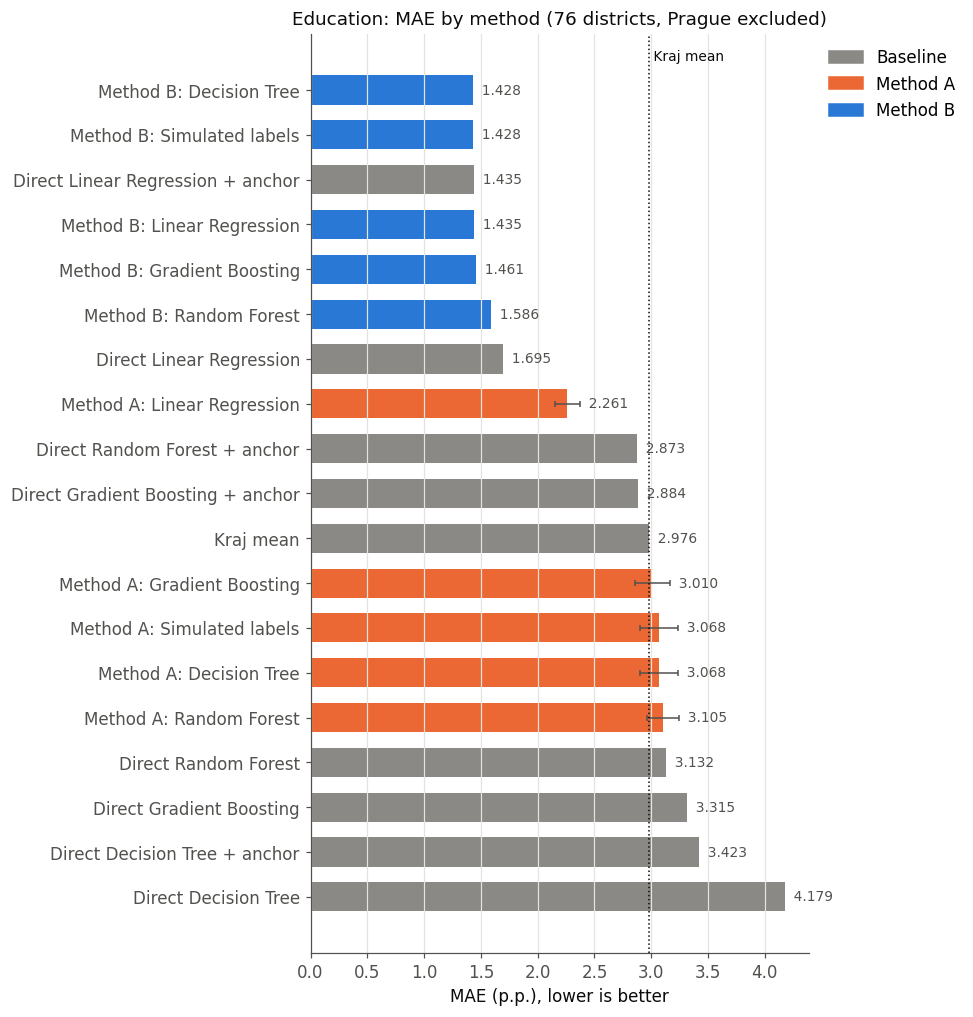

In [9]:
plotting.comparison_bars(comparison, 'Education: MAE by method (76 districts, Prague excluded)',
                         PLOTS / 'comparison_mae.png');

## 5. Are the differences real? (paired bootstrap)

With 76 districts, small MAE differences can be chance. We resample the districts 2000 times (the same draw for every method, so comparisons are paired) and recompute each MAE.

* **Δ vs Kraj mean** - MAE difference to the Kraj-mean baseline; negative = better. If the 95% interval excludes 0, the improvement is unlikely to be chance.
* **P(better)** - share of resamples in which the method beats the baseline.

Districts in the same Kraj have correlated errors, so we repeat the test resampling *whole Kraje* (13 regions) - a stricter test with wider intervals. Method A errors are averaged over all seeds.

In [10]:
errors = approx.abs_errors({
    **baseline_preds,
    **{f'Method A: {k}': v for k, v in runs_a.items() if k != 'Simulated labels'},
    **{f'Method B: {k}': v for k, v in runs_b.items() if k != 'Simulated labels'}}, ds)
boot_okres = approx.bootstrap(errors, ds, by='okres')
boot_kraj = approx.bootstrap(errors, ds, by='kraj')
boot = boot_okres.join(boot_kraj[['Δ 2.5%', 'Δ 97.5%', 'P(better)']], rsuffix=' (by Kraj)')
boot.to_csv(RESULTS / 'bootstrap_vs_kraj_mean.csv')
boot

,MAE,MAE 2.5%,MAE 97.5%,Δ vs Kraj mean,Δ 2.5%,Δ 97.5%,P(better),Δ 2.5% (by Kraj),Δ 97.5% (by Kraj),P(better) (by Kraj)
Method,,,,,,,,,,
Method B: Decision Tree,1.428,1.162,1.718,-1.548,-2.112,-1.045,1.000,-2.514,-0.740,1.000e+00
Direct Linear Regression + anchor,1.435,1.171,1.720,-1.541,-2.109,-1.032,1.000,-2.492,-0.723,1.000e+00
Method B: Linear Regression,1.435,1.179,1.713,-1.541,-2.115,-1.037,1.000,-2.538,-0.730,1.000e+00
Method B: Gradient Boosting,1.461,1.201,1.737,-1.515,-2.060,-1.044,1.000,-2.448,-0.761,1.000e+00
Method B: Random Forest,1.586,1.282,1.918,-1.390,-1.842,-0.967,1.000,-2.358,-0.691,1.000e+00
Direct Linear Regression,1.695,1.366,2.016,-1.281,-1.850,-0.740,1.000,-2.254,-0.492,1.000e+00
Method A: Linear Regression,2.261,1.855,2.741,-0.715,-0.980,-0.445,1.000,-1.215,-0.330,1.000e+00
Direct Random Forest + anchor,2.873,2.410,3.398,-0.103,-0.420,0.238,0.716,-0.723,0.370,5.890e-01
Direct Gradient Boosting + anchor,2.884,2.357,3.476,-0.092,-0.698,0.487,0.613,-1.214,0.728,5.150e-01


**Head-to-head among the best methods.** Paired bootstrap of the MAE difference between each pair of the top five methods (negative = A better).

In [11]:
top = boot_okres.index[:5].tolist()
pairs = approx.pairwise(errors, ds, top)
pairs_kraj = approx.pairwise(errors, ds, top, by='kraj')
pairs = pairs.join(pairs_kraj[['2.5%', '97.5%', 'P(A better)']], rsuffix=' (by Kraj)')
pairs.to_csv(RESULTS / 'bootstrap_pairwise_top.csv', index=False)
pairs

,A,B,MAE(A) - MAE(B),2.5%,97.5%,P(A better),2.5% (by Kraj),97.5% (by Kraj),P(A better) (by Kraj)
0,Method B: Decision Tree,Direct Linear Regression + anchor,-6.808e-03,-0.024,0.010,0.794,-0.027,0.014,0.731
1,Method B: Decision Tree,Method B: Linear Regression,-6.957e-03,-0.039,0.026,0.664,-0.060,0.041,0.605
2,Method B: Decision Tree,Method B: Gradient Boosting,-3.250e-02,-0.128,0.065,0.764,-0.102,0.030,0.831
3,Method B: Decision Tree,Method B: Random Forest,-1.577e-01,-0.379,0.071,0.923,-0.325,0.026,0.957
4,Direct Linear Regression + anchor,Method B: Linear Regression,-1.488e-04,-0.037,0.038,0.509,-0.054,0.052,0.517
5,Direct Linear Regression + anchor,Method B: Gradient Boosting,-2.569e-02,-0.127,0.077,0.699,-0.095,0.038,0.772
6,Direct Linear Regression + anchor,Method B: Random Forest,-1.509e-01,-0.377,0.086,0.903,-0.326,0.046,0.936
7,Method B: Linear Regression,Method B: Gradient Boosting,-2.554e-02,-0.108,0.060,0.734,-0.095,0.043,0.762
8,Method B: Linear Regression,Method B: Random Forest,-1.508e-01,-0.363,0.060,0.922,-0.303,0.045,0.946
9,Method B: Gradient Boosting,Method B: Random Forest,-1.252e-01,-0.322,0.076,0.900,-0.264,0.036,0.934


## 6. Sensitivity of Method A to the noise level

Method A uses `CV = 0.1`. We rerun it over a grid of noise levels (20 seeds each). `CV = 0` means the simulated labels are simply the Kraj value - no noise at all - so the curve shows what the noise itself adds. The second table varies how the noise is split between cluster-level and district-level (`cluster_share`) at the chosen CV.

model,Linear Regression,Decision Tree,Random Forest,Gradient Boosting
cv,,,,
0.00,2.280,2.976,3.076,2.972
0.02,2.271,2.970,3.072,2.960
0.04,2.262,2.977,3.067,2.959
0.06,2.254,2.994,3.066,2.960
0.08,2.245,3.020,3.068,2.975
0.10,2.237,3.055,3.083,2.992
0.15,2.217,3.192,3.127,3.065
0.20,2.199,3.388,3.209,3.186


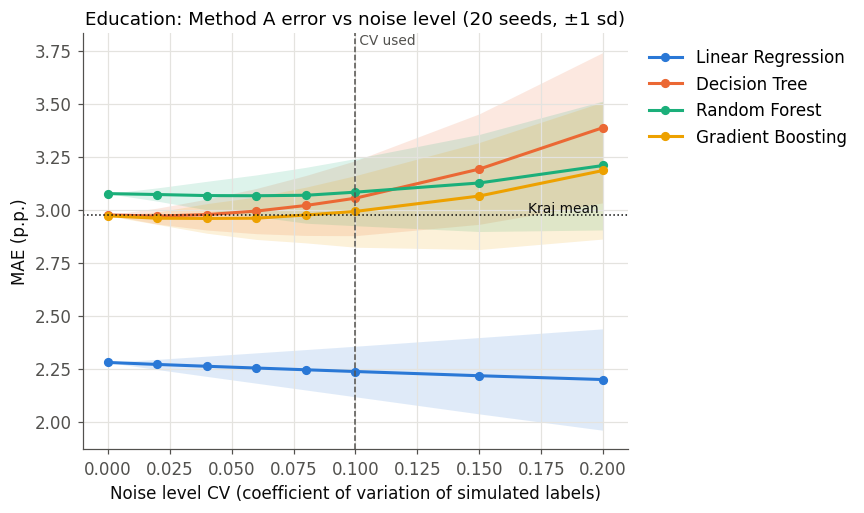

In [12]:
models = list(approx.make_models())
CV_GRID = [0.0, 0.02, 0.04, 0.06, 0.08, 0.10, 0.15, 0.20]
sens = approx.method_a_sensitivity(ds, clusters, CV_GRID)
sens.to_csv(RESULTS / 'method_a_sensitivity_cv.csv', index=False)
plotting.sensitivity_lines(sens, comparison.loc['Kraj mean', 'MAE'], CV,
                           'Education: Method A error vs noise level (20 seeds, ±1 sd)',
                           PLOTS / 'method_a_sensitivity_cv.png');
sens.pivot(index='cv', columns='model', values='MAE')[models]

In [13]:
sens_share = approx.method_a_sensitivity(ds, clusters, [CV], cluster_shares=[0.0, 0.25, 0.5, 0.75, 1.0])
sens_share.to_csv(RESULTS / 'method_a_sensitivity_cluster_share.csv', index=False)
sens_share.pivot(index='cluster_share', columns='model', values='MAE')[models]

model,Linear Regression,Decision Tree,Random Forest,Gradient Boosting
cluster_share,,,,
0.00,2.270,3.116,3.130,3.040
0.25,2.246,3.077,3.096,3.002
0.50,2.237,3.055,3.083,2.992
0.75,2.232,3.035,3.065,2.977
1.00,2.235,3.022,3.066,2.979


## 7. Figures

Method A scatter plots show a single draw (seed 0); the error spread over draws is in `MAE sd` above.

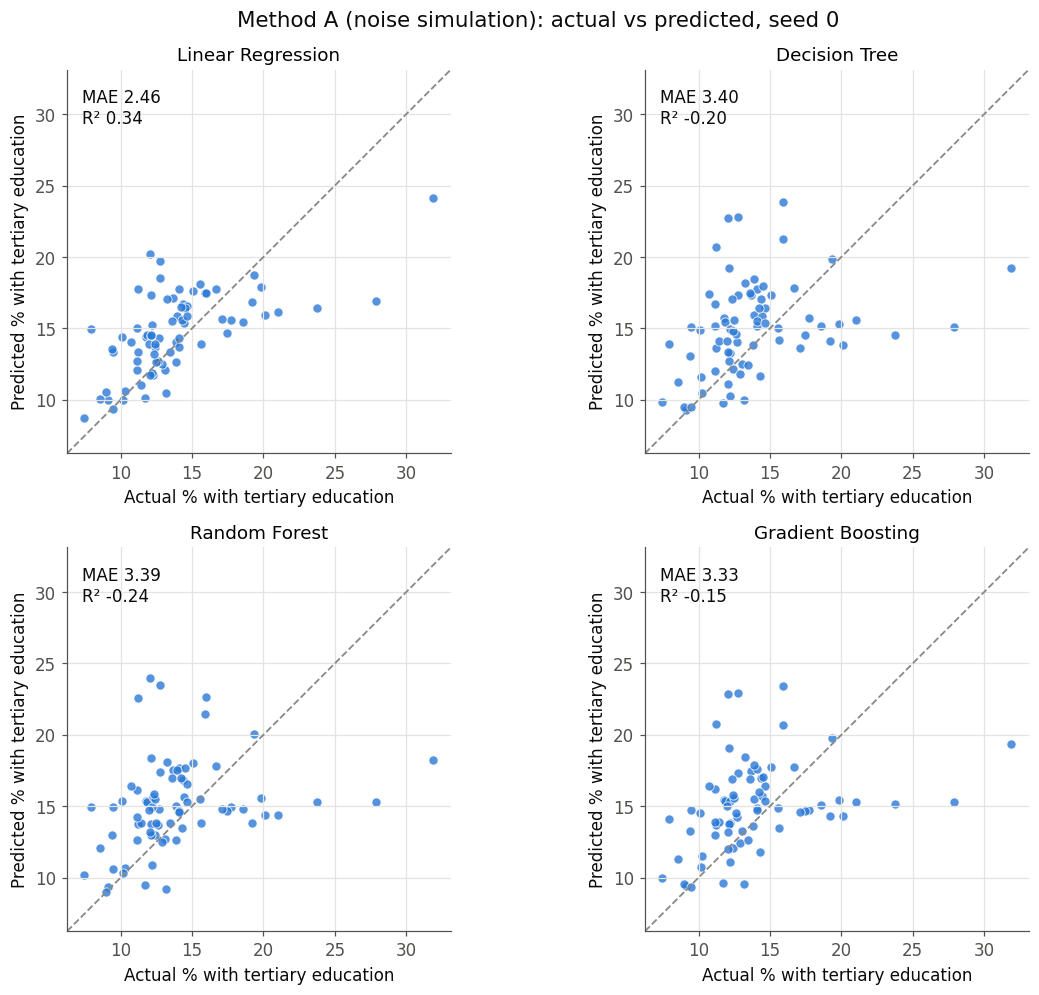

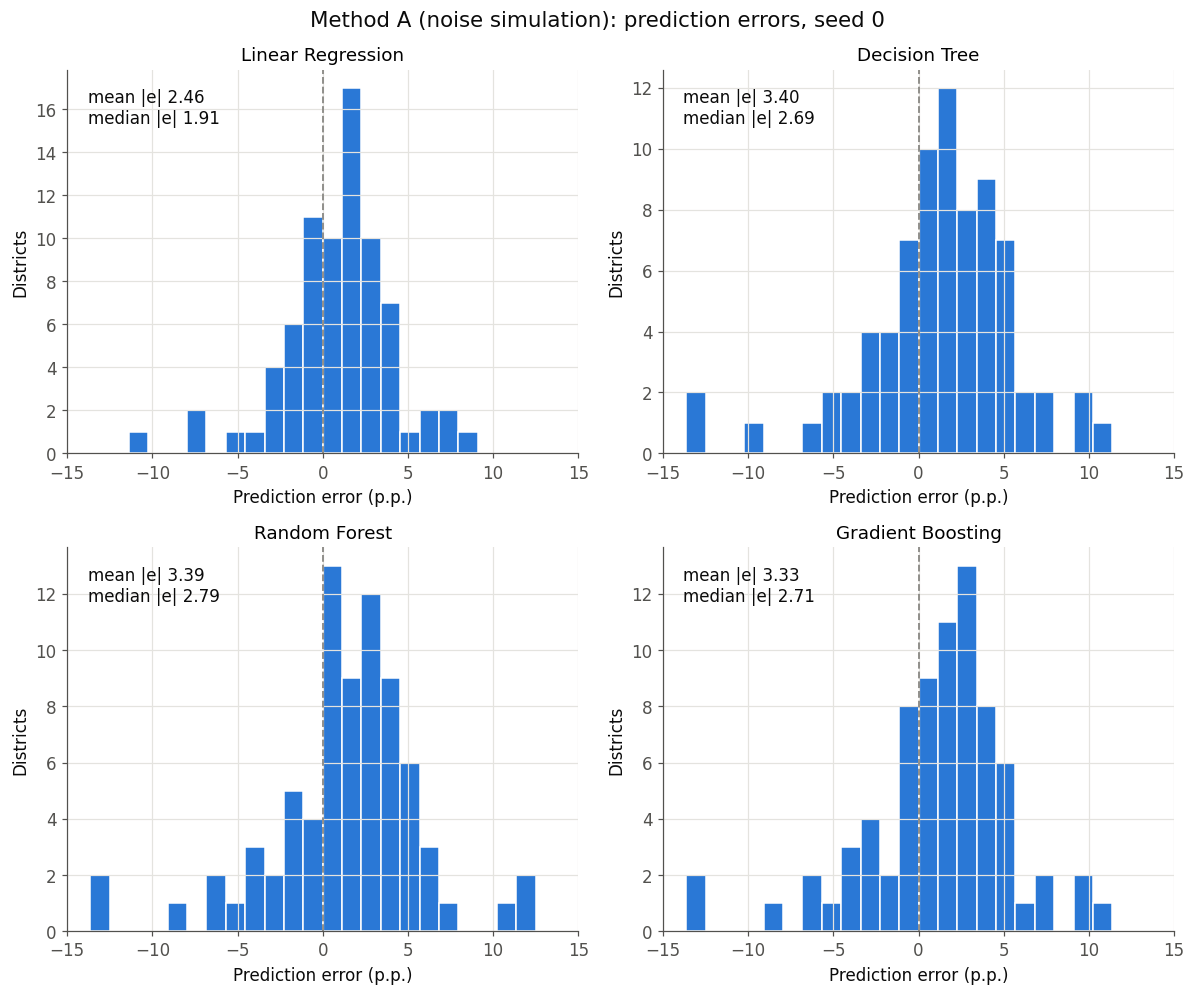

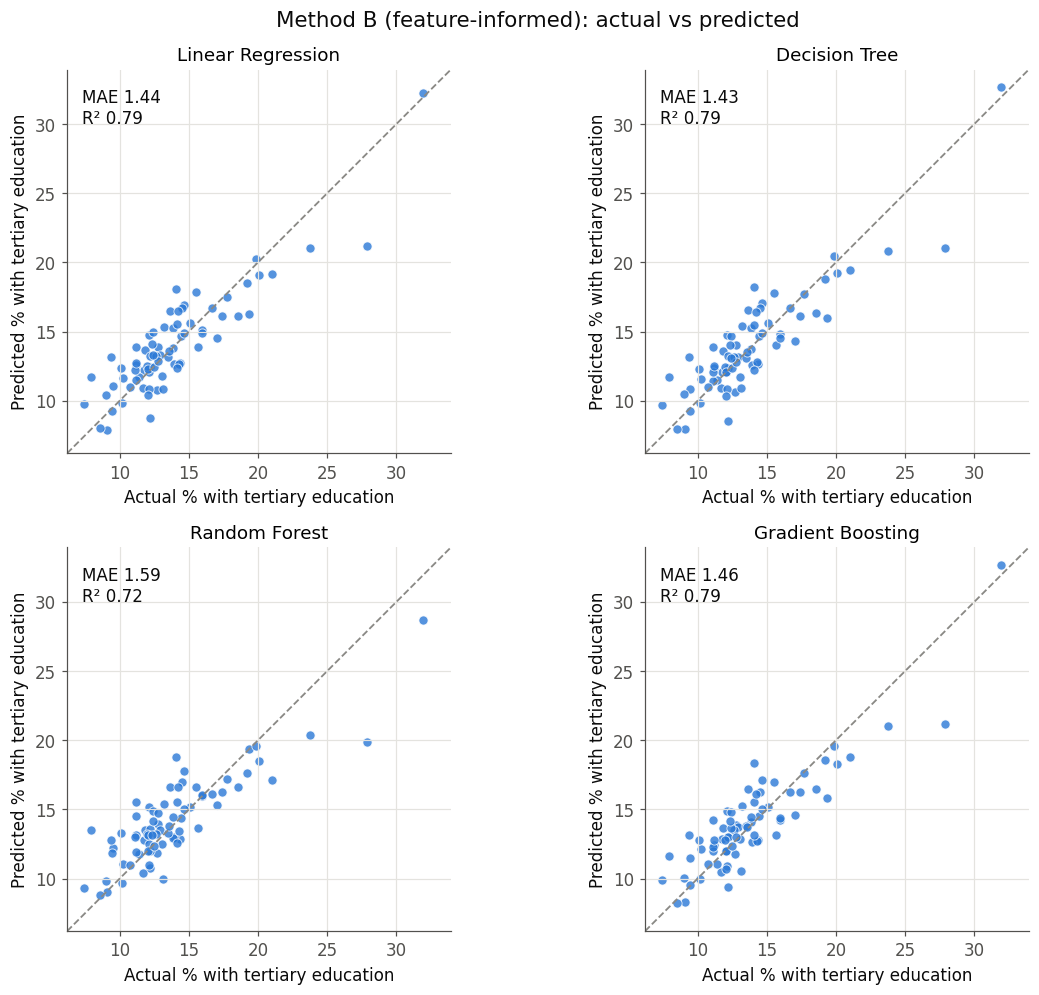

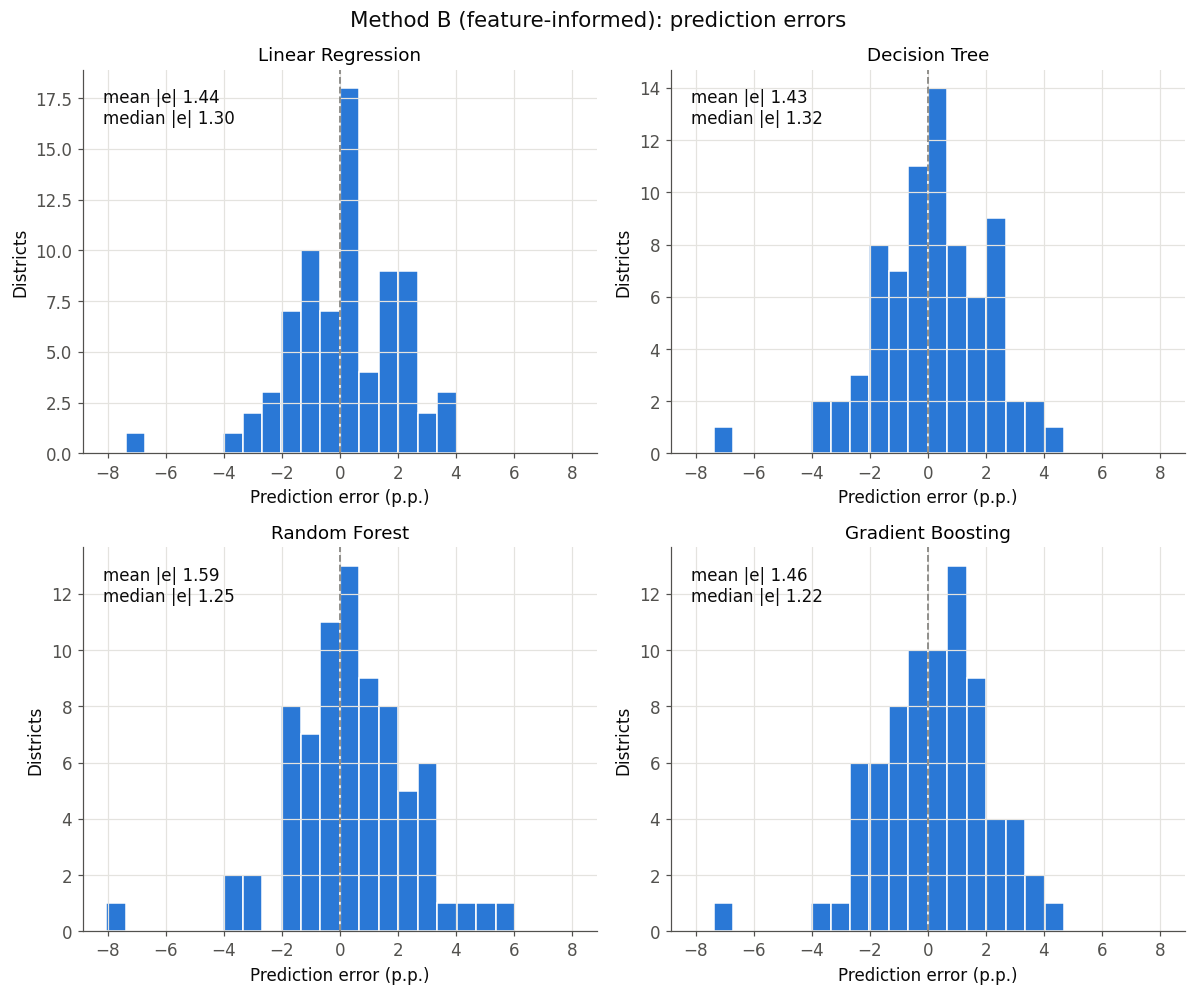

In [14]:
models = list(approx.make_models())
preds_a = {m: runs_a[m][0] for m in models}
preds_b = {m: runs_b[m][0] for m in models}
plotting.prediction_grid(ds, preds_a, 'Method A (noise simulation): actual vs predicted, seed 0',
                         PLOTS / 'method_a_prediction_comparison.png');
plotting.error_grid(ds, preds_a, 'Method A (noise simulation): prediction errors, seed 0',
                    PLOTS / 'method_a_error_distribution.png');
plotting.prediction_grid(ds, preds_b, 'Method B (feature-informed): actual vs predicted',
                         PLOTS / 'method_b_prediction_comparison.png');
plotting.error_grid(ds, preds_b, 'Method B (feature-informed): prediction errors',
                    PLOTS / 'method_b_error_distribution.png');

## 8. Save predictions

Method A predictions are averaged over all seeds.

In [15]:
all_preds = {**baseline_preds,
             **{f'Method A: {k}': v for k, v in runs_a.items()},
             **{f'Method B: {k}': v for k, v in runs_b.items()}}
approx.predictions_frame(ds, all_preds).to_csv(RESULTS / 'predictions.csv')
print(f"saved {RESULTS / 'predictions.csv'} and {RESULTS / 'comparison_metrics.csv'}")

saved results\predictions.csv and results\comparison_metrics.csv
